# 03 · Optimize — assign forecast volume to distribution centers
**Question:** given the forecast, how should each region's demand be split across DCs to stay within capacity at lowest cost?

**LP (solved each forecast week with PuLP + HiGHS)**

$$\min \sum_{r,d}(s_{rd}+h_d)\,x_{rd} + P\sum_r o_r \quad \text{s.t.}\quad \sum_d x_{rd}+o_r=D_r\ \forall r,\qquad \sum_r x_{rd}\le C_d\ \forall d,\qquad x,o\ge 0$$

`s` = shipping $/unit (distance-based), `h` = handling $/unit at the DC, `o` = 3PL overflow lane at P = $3/unit so any capacity shortfall is quantified rather than hiding as infeasibility.

> **Assumptions to be upfront about:** M5 has no DC data, so the 4 DCs, their capacities, handling costs and the shipping-rate formula are **synthetic inputs I created** (see `src/network.py`); capacities were set so the network is ~85–90% utilized. Conclusions are about the method and the shape of the trade-offs, not real dollars.

In [1]:
import pandas as pd
from IPython.display import Image
dcs = pd.read_csv("../data/dc_network.csv"); ship = pd.read_csv("../data/shipping_costs.csv")
display(dcs)
ship.pivot(index="region", columns="dc", values="ship_cost_per_unit")

,dc,city,lat,lon,weekly_capacity,handling_cost_per_unit
0,DC1,"Phoenix, AZ",33.45,-112.07,100000,0.50
1,DC2,"Dallas, TX",32.78,-96.80,90000,0.55
2,DC3,"Chicago, IL",41.88,-87.63,95000,0.65
3,DC4,"Atlanta, GA",33.75,-84.39,80000,0.60


dc,DC1,DC2,DC3,DC4
region,,,,
Midwest,1.392,0.879,0.219,0.719
South,1.012,0.341,0.951,0.746
West,0.453,1.202,1.631,1.793


In [2]:
import sys; sys.path.insert(0, "../src")
import inspect, optimize
print(inspect.getsource(optimize.solve_lp))

def solve_lp(demand, cap):
    m = pulp.LpProblem("dc_assign", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("x", UNIT.keys(), lowBound=0)
    o = pulp.LpVariable.dicts("o", REG_IDS, lowBound=0)
    m += pulp.lpSum(UNIT[k] * x[k] for k in UNIT) + OVERFLOW_COST * pulp.lpSum(o.values())
    for r in REG_IDS:
        m += pulp.lpSum(x[r, d] for d in DC_IDS) + o[r] == demand[r]
    for d in DC_IDS:
        m += pulp.lpSum(x[r, d] for r in REG_IDS) <= cap[d]
    m.solve(pulp.HiGHS(msg=False))
    assert pulp.LpStatus[m.status] == "Optimal", pulp.LpStatus[m.status]
    flows = {k: x[k].value() for k in UNIT}
    over = {r: o[r].value() for r in REG_IDS}
    return flows, over



In [3]:
# run all scenarios (writes data/outputs/*.csv)
optimize.main()

  demand_case                             scenario      demand       total  over_units  expansion  savings_vs_asis  savings_vs_asis_pct  cost_per_unit  breakeven_$per_unit_cap_wk
0        base   0 As-is (home DC + pro-rata spill)  3714386.88  3969306.28         0.0        0.0             0.00                 0.00           1.07                         NaN
1        base       1 Optimized - current capacity  3714386.88  3873784.83         0.0        0.0         95521.45                 2.41           1.04                         NaN
2        base  2 Optimized + 30k/wk at DC1 Phoenix  3714386.88  3579485.92         0.0   144000.0        389820.36                 9.82           0.96                        1.22
3        base   3 Optimized + 30k/wk at DC2 Dallas  3714386.88  3867125.92         0.0   144000.0        102180.36                 2.57           1.04                        0.42
4        high   0 As-is (home DC + pro-rata spill)  4185825.74  4709694.34         0.0        0.0        

In [4]:
summ = pd.read_csv("../data/outputs/scenario_summary.csv")
summ[summ.demand_case=="base"][["scenario","total","expansion","savings_vs_asis","savings_vs_asis_pct","cost_per_unit","breakeven_$per_unit_cap_wk"]].round(2)

,scenario,total,expansion,savings_vs_asis,savings_vs_asis_pct,cost_per_unit,breakeven_$per_unit_cap_wk
0,0 As-is (home DC + pro-rata spill),3969306.28,0.0,0.00,0.00,1.07,NaN
1,1 Optimized - current capacity,3873784.83,0.0,95521.45,2.41,1.04,NaN
2,2 Optimized + 30k/wk at DC1 Phoenix,3579485.92,144000.0,389820.36,9.82,0.96,1.22
3,3 Optimized + 30k/wk at DC2 Dallas,3867125.92,144000.0,102180.36,2.57,1.04,0.42


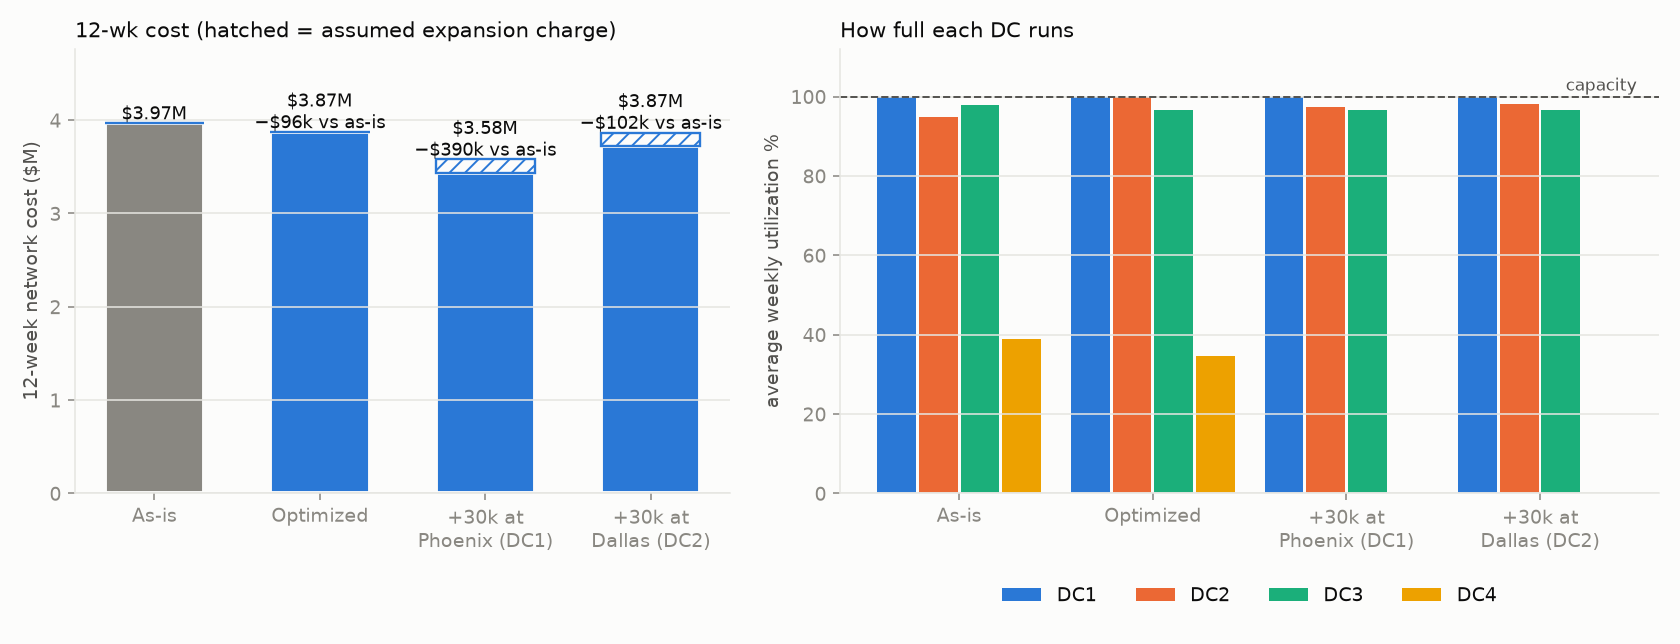

In [5]:
Image("../assets/06_scenarios_cost_utilization.png")

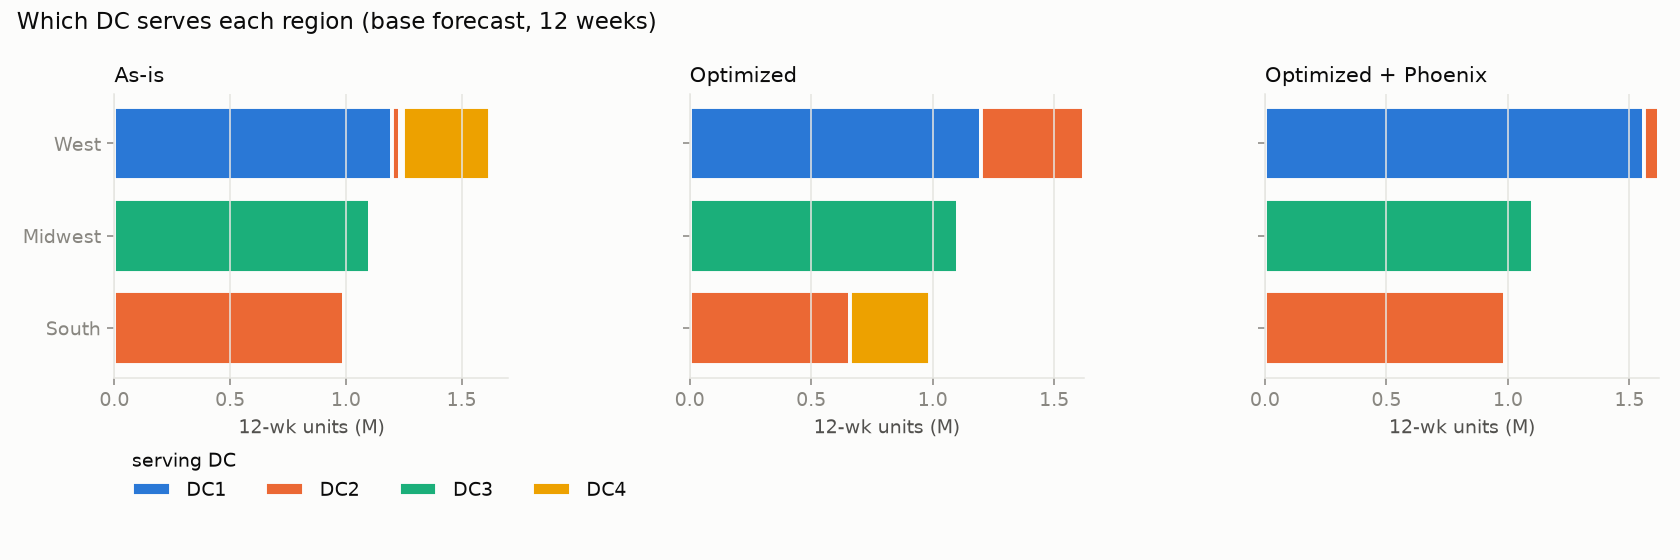

In [6]:
Image("../assets/07_flows_by_scenario.png")

## What the model says (base forecast, 12 weeks)
* **Optimization alone, no new capacity: saves about USD 96k (2.4%)** vs the cost-blind home-DC rule. The LP sends West overflow to Dallas and lets South use idle Atlanta capacity, instead of spilling West volume to Atlanta.
* **+30k units/week at Phoenix (DC1):** operating cost falls about USD 438k; after an assumed USD 144k expansion charge (0.40 USD per unit-week) the **net gain is about USD 294k vs optimized-only** (about USD 390k / 9.8% vs as-is). It stays positive up to about **1.22 USD per unit-week** (the breakeven price).
* **+30k units/week at Dallas (DC2):** gross saving about USD 151k, net about **USD 7k**; breakeven 0.42 vs 0.40 assumed. Essentially break-even, so **not worth doing** unless expansion costs less than about 0.42 USD per unit-week.
* **Atlanta (DC4) runs about 35% full** and sits idle once Phoenix is expanded, so it is a candidate to right-size, sublease or re-purpose.
* **High-demand stress case** (upper 80% band, +12.7% volume): the network is full at DC1-DC3 and relies on Atlanta; the Phoenix expansion nets about USD 307k, Dallas about USD 20k. Same ranking.

In [7]:
print(summ[summ.demand_case=="high"][["scenario","total","savings_vs_asis","savings_vs_asis_pct","breakeven_$per_unit_cap_wk"]].round(2).to_string())
util = pd.read_csv("../data/outputs/dc_utilization.csv")
util[util.scenario.str.startswith("1")].groupby(["demand_case","dc"]).utilization.agg(["mean","max"]).round(3)

                              scenario       total  savings_vs_asis  savings_vs_asis_pct  breakeven_$per_unit_cap_wk
4   0 As-is (home DC + pro-rata spill)  4709694.34             0.00                 0.00                         NaN
5       1 Optimized - current capacity  4604231.15        105463.19                 2.24                         NaN
6  2 Optimized + 30k/wk at DC1 Phoenix  4296791.15        412903.19                 8.77                        1.25
7   3 Optimized + 30k/wk at DC2 Dallas  4584431.15        125263.19                 2.66                        0.46


mean    max
demand_case dc               
base        DC1  1.000  1.000
            DC2  1.000  1.000
            DC3  0.967  0.988
            DC4  0.346  0.382
high        DC1  1.000  1.000
            DC2  1.000  1.000
            DC3  1.000  1.000
            DC4  0.798  0.853